## PART - B

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3
import requests
import json

### Load csv dataset

In [ ]:
df_csv = pd.read_csv("advanced_customer_data.csv")
df_csv.head()

,CustomerID,Age,Gender,Income,PurchaseFrequency,AvgPurchaseValue,Tenure,Churn
0,1,56.0,Male,139677.0,18,330.11,1,0
1,2,69.0,Female,191422.0,13,357.65,8,0
2,3,46.0,Female,158273.0,37,508.11,8,0
3,4,32.0,Male,44426.0,35,NaN,1,0
4,5,NaN,Male,32778.0,39,876.94,9,1


### Load JSON datasset

In [ ]:
with open("advanced_customer_data.json") as f:
    data = json.load(f)

df_json = pd.DataFrame(data)
df_json.head()

,CustomerID,Age,Gender,Income,PurchaseFrequency,AvgPurchaseValue,Tenure,Churn
0,1,56.0,Male,139677.0,18,330.11,1,0
1,2,69.0,Female,191422.0,13,357.65,8,0
2,3,46.0,Female,158273.0,37,508.11,8,0
3,4,32.0,Male,44426.0,35,NaN,1,0
4,5,NaN,Male,32778.0,39,876.94,9,1


### Load Sql dataset

In [ ]:
conn = sqlite3.connect('advanced_customer_data.db')
pd.read_sql('SELECT * FROM customers LIMIT 5', conn)

,CustomerID,Age,Gender,Income,PurchaseFrequency,AvgPurchaseValue,Tenure,Churn
0,1,56.0,Male,139677.0,18,330.11,1,0
1,2,69.0,Female,191422.0,13,357.65,8,0
2,3,46.0,Female,158273.0,37,508.11,8,0
3,4,32.0,Male,44426.0,35,NaN,1,0
4,5,NaN,Male,32778.0,39,876.94,9,1


### API calling

In [ ]:
url = "https://jsonplaceholder.typicode.com/users"

response = requests.get(url)
api_data = response.json()

df_api =pd.DataFrame(api_data)
df_api.head()

,id,name,username,email,address,phone,website,company
0,1,Leanne Graham,Bret,Sincere@april.biz,"{'street': 'Kulas Light', 'suite': 'Apt. 556',...",1-770-736-8031 x56442,hildegard.org,"{'name': 'Romaguera-Crona', 'catchPhrase': 'Mu..."
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,"{'street': 'Victor Plains', 'suite': 'Suite 87...",010-692-6593 x09125,anastasia.net,"{'name': 'Deckow-Crist', 'catchPhrase': 'Proac..."
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,"{'street': 'Douglas Extension', 'suite': 'Suit...",1-463-123-4447,ramiro.info,"{'name': 'Romaguera-Jacobson', 'catchPhrase': ..."
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,"{'street': 'Hoeger Mall', 'suite': 'Apt. 692',...",493-170-9623 x156,kale.biz,"{'name': 'Robel-Corkery', 'catchPhrase': 'Mult..."
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,"{'street': 'Skiles Walks', 'suite': 'Suite 351...",(254)954-1289,demarco.info,"{'name': 'Keebler LLC', 'catchPhrase': 'User-c..."


## PART - C

In [ ]:
df_csv.head()
df_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         1200 non-null   int64  
 1   Age                1080 non-null   float64
 2   Gender             1200 non-null   object 
 3   Income             1080 non-null   float64
 4   PurchaseFrequency  1200 non-null   int64  
 5   AvgPurchaseValue   1080 non-null   float64
 6   Tenure             1200 non-null   int64  
 7   Churn              1200 non-null   int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 75.1+ KB


In [ ]:
df_csv.describe()

,CustomerID,Age,Income,PurchaseFrequency,AvgPurchaseValue,Tenure,Churn
count,1200.000000,1080.000000,1080.000000,1200.000000,1080.000000,1200.000000,1200.000000
mean,600.500000,43.450926,119440.899074,19.580000,517.935833,4.980000,0.291667
std,346.554469,15.085158,78674.055590,11.557678,330.344094,2.596514,0.454719
min,1.000000,18.000000,15155.000000,0.000000,5.030000,1.000000,0.000000
25%,300.750000,30.000000,63297.750000,10.000000,246.717500,3.000000,0.000000
50%,600.500000,43.000000,113793.500000,20.000000,503.275000,5.000000,0.000000
75%,900.250000,56.000000,161727.750000,29.000000,751.637500,7.000000,1.000000
max,1200.000000,69.000000,587214.000000,39.000000,1980.760000,9.000000,1.000000


In [ ]:
df_csv.isnull().sum()

,0
CustomerID,0
Age,120
Gender,0
Income,120
PurchaseFrequency,0
AvgPurchaseValue,120
Tenure,0
Churn,0


In [ ]:
df_csv['Age'].fillna(df_csv['Age'].median(), inplace=True)
df_csv['Income'].fillna(df_csv['Income'].median(), inplace=True)
df_csv['AvgPurchaseValue'].fillna(df_csv['AvgPurchaseValue'].mean(), inplace=True)

/tmp/ipykernel_500/1506868764.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_csv['Age'].fillna(df_csv['Age'].median(), inplace=True)
/tmp/ipykernel_500/1506868764.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [ ]:
df_csv.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Income,0
PurchaseFrequency,0
AvgPurchaseValue,0
Tenure,0
Churn,0


In [ ]:
df_csv.duplicated().sum()

np.int64(0)

## PART - D

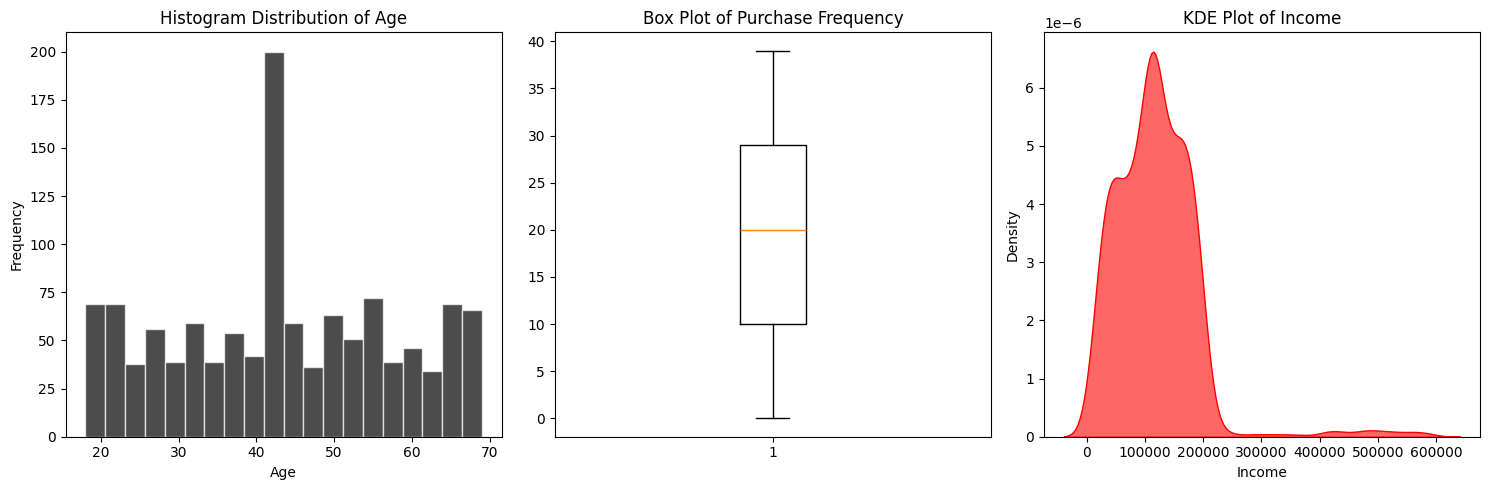

Skewness: -0.00
Kurtosis: -0.97


In [ ]:
# univariate analysis

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))


axes[0].hist(df_csv["Age"], bins=20, color="black", edgecolor="white", alpha=0.7)
axes[0].set_title("Histogram Distribution of Age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")


axes[1].boxplot(df_csv["PurchaseFrequency"])
axes[1].set_title("Box Plot of Purchase Frequency")

sns.kdeplot(df_csv["Income"], ax=axes[2], color="red", fill=True, alpha=0.6)
axes[2].set_title("KDE Plot of Income")


plt.tight_layout()
plt.savefig("univariate analysis.png", dpi=300)
plt.show()


print(f"Skewness: {df_csv['Age'].skew():.2f}")
print(f"Kurtosis: {df_csv['Age'].kurtosis():.2f}")


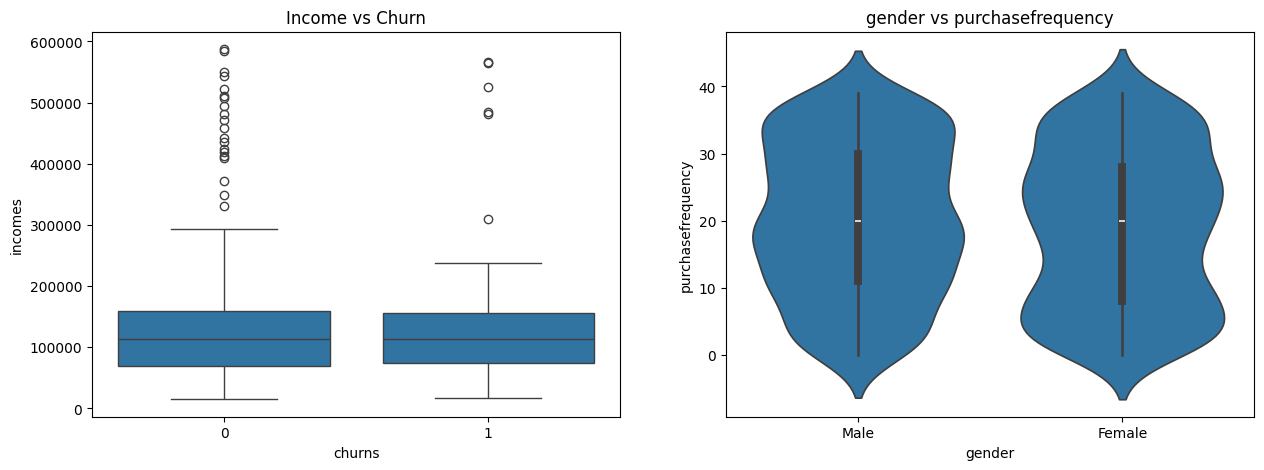

In [ ]:
# bivariate analysis

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x='Churn', y='Income',ax=axes[0] ,data=df_csv)
axes[0].set_title("Income vs Churn")
axes[0].set_xlabel("churns")
axes[0].set_ylabel("incomes")



sns.violinplot(x='Gender', y='PurchaseFrequency',ax=axes[1] ,data=df_csv)
axes[1].set_title("gender vs purchasefrequency")
axes[1].set_xlabel("gender")
axes[1].set_ylabel("purchasefrequency")
plt.savefig("bivariate analysis.png", dpi=300)
plt.show()





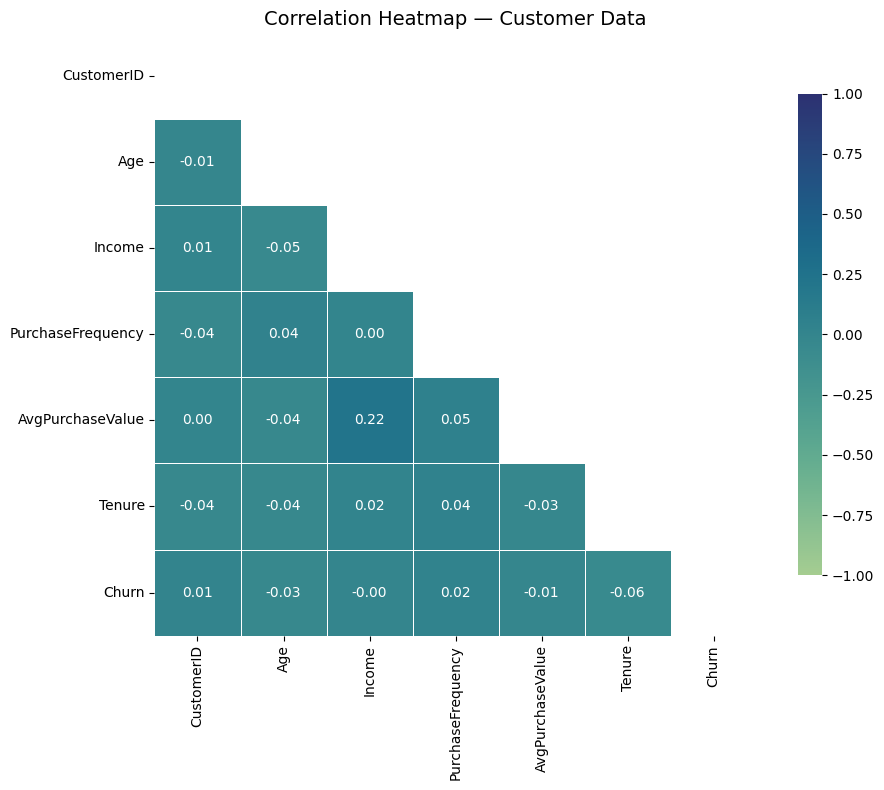

In [ ]:
# multivariate analysis

corr_matrix = df_csv.select_dtypes(include='number').corr()

# Heatmap
plt.figure(figsize=(10, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='crest',
    mask=mask,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title("Correlation Heatmap — Customer Data", fontsize=14)
plt.tight_layout()
plt.savefig("multivariate analysis.png", dpi=300)

plt.show()


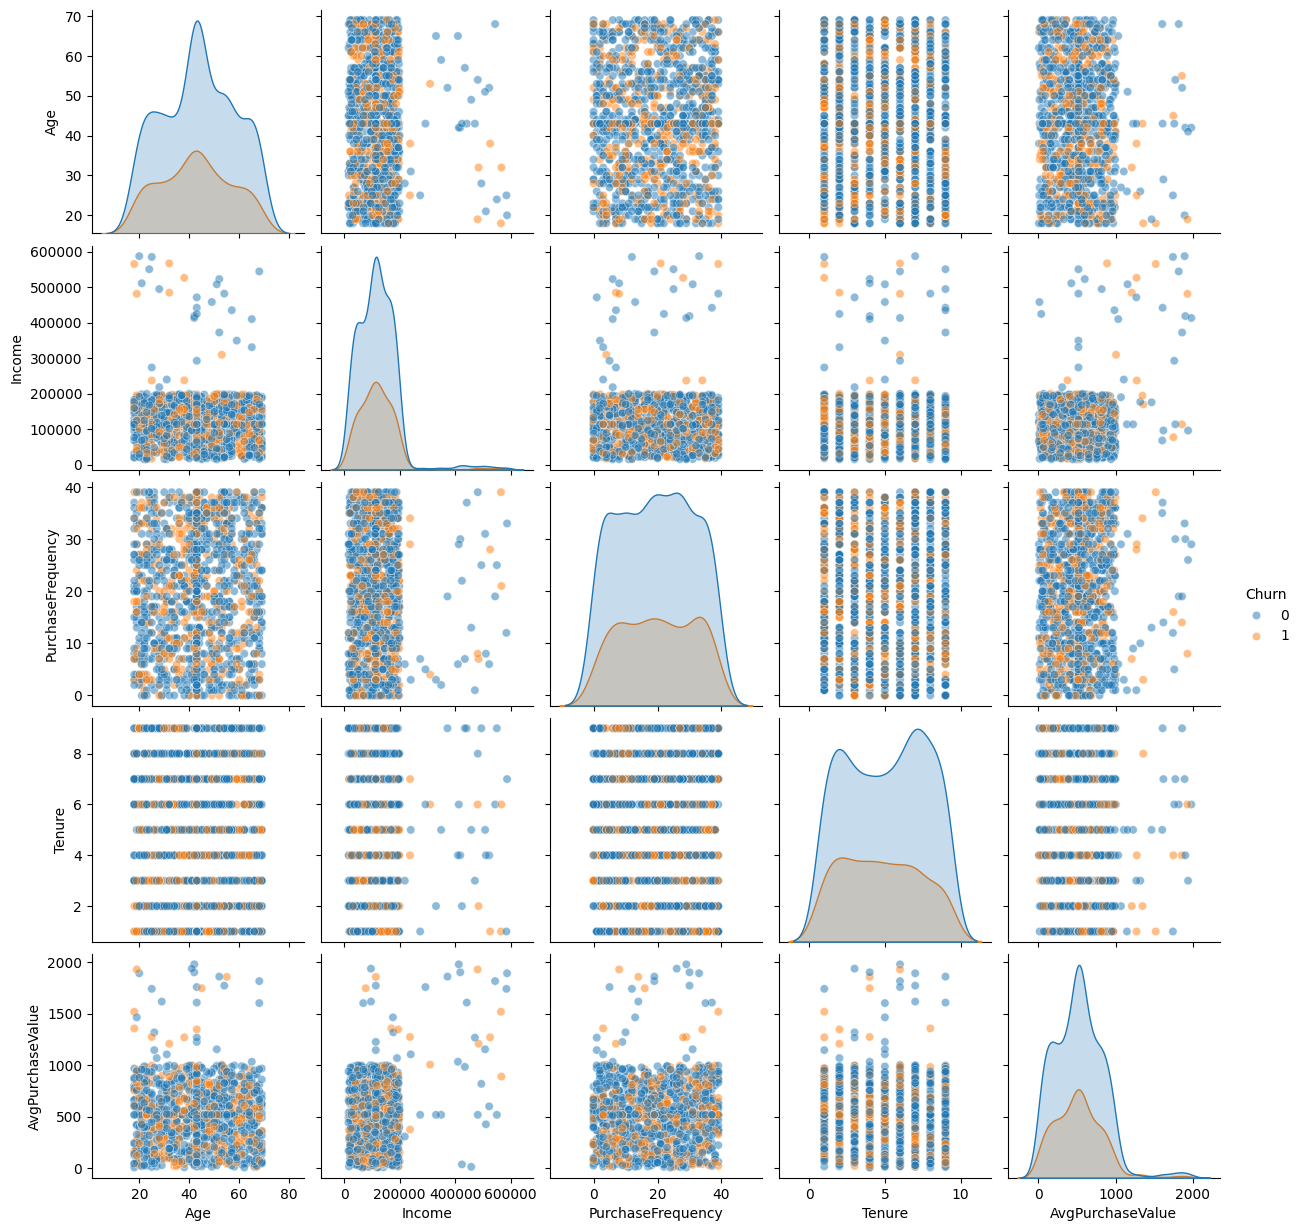

In [ ]:
sns.pairplot(
    df_csv[['Age', 'Income', 'PurchaseFrequency', 'Tenure', 'Churn', 'AvgPurchaseValue']],
    hue='Churn',
    diag_kind='kde',
    plot_kws={'alpha': 0.5}
)
plt.savefig("pairplot.png", dpi=300)

plt.show()


## PART - E

In [ ]:

!pip install ydata_profiling
import pandas as pd
from ydata_profiling import ProfileReport


df_json = pd.read_json("advanced_customer_data.json")


profile = ProfileReport(
    df_json,
    title="Customer Data Profiling Report",
    explorative=True
)


profile.to_file("customer_data_report.html")

print("Full report generated successfully!")


profile.to_notebook_iframe()


profile_minimal = ProfileReport(
    df_json,
    title="Quick Data Profiling Report",
    minimal=True
)

profile_minimal.to_file("quick_report.html")

print("Quick report generated successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 6.3 MB/s eta 0:00:00


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 55.90it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

...


100%|██████████| 8/8 [00:00<00:00, 82.79it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Quick report generated successfully!
